In [2]:
import cv as cv
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
invoice = cv.imread("data/invoice1.jpg")
invoice_rgb = cv.imread("data/invoice1.jpg", cv.COLOR_BGR2RGB)

In [60]:
if invoice is None:
    print("NO img here go away")
else: 
    cv.imshow("invoice binary", invoice_binary)
    cv.waitKey(0)
    cv.destroyAllWindows()

In [4]:

def to_grayscale(image: np.ndarray) -> np.ndarray:
    if image is None:
        raise ValueError("Input image is None. Check that the image was loaded correctly.")

    if len(image.shape) == 2:
        return image

    if len(image.shape) == 3 and image.shape[2] == 3:
        gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        return gray_image

    raise ValueError(
        f"Unsupported image shape: {image.shape}. Expected (H, W) or (H, W, 3)."
    )

In [23]:
ouput_invoice = to_grayscale(invoice)

In [24]:
oupute = to_grayscale(cv.imread("data/invoice complex.jpg"))

In [26]:
cv.imwrite("invoice_cpx.png", oupute)

True

In [25]:
oupute.shape

(1631, 1275)

In [5]:
def load_image(image_path: str) -> np.ndarray:
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image path does not exist: {image_path}")

    image = cv.imread(image_path)

    if image is None:
        raise ValueError(f"Failed to load image from path: {image_path}")

    return image


In [9]:
def debug_preprocessing_step(
    image,
    processing_function,
    save_path: str = None,
    **kwargs
) -> np.ndarray:
   

   # Handle both path and array input
    if isinstance(image, str):
        original_image = cv.imread(image)
        input_source = image
    elif isinstance(image, np.ndarray):
        original_image = image.copy()
        input_source = "numpy array"
    else:
        raise ValueError("Input must be a file path (str) or NumPy array.")

    # Step 2: apply the preprocessing function
    processed_image = processing_function(original_image, **kwargs)

    # Step 3: validate output
    if not isinstance(processed_image, np.ndarray):
        raise ValueError(
            f"The processing function '{processing_function.__name__}' "
            f"did not return a NumPy array."
        )

    # Step 4: print useful debug information
    print("=" * 60)
    print(f"Processing function : {processing_function.__name__}")
    print(f"Original shape      : {original_image.shape}")
    print(f"Processed shape     : {processed_image.shape}")
    print(f"Original dtype      : {original_image.dtype}")
    print(f"Processed dtype     : {processed_image.dtype}")
    print("=" * 60)

    # Step 5: prepare images for matplotlib display
    # OpenCV loads color images in BGR, but matplotlib expects RGB.
    if len(original_image.shape) == 3 and original_image.shape[2] == 3:
        original_display = cv.cvtColor(original_image, cv.COLOR_BGR2RGB)
    else:
        original_display = original_image

    if len(processed_image.shape) == 3 and processed_image.shape[2] == 3:
        processed_display = cv.cvtColor(processed_image, cv.COLOR_BGR2RGB)
        processed_cmap = None
    else:
        processed_display = processed_image
        processed_cmap = "gray"

    original_cmap = None if len(original_display.shape) == 3 else "gray"

    # Step 6: visualize side-by-side
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_display, cmap=original_cmap)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed_display, cmap=processed_cmap)
    plt.title(f"Processed: {processing_function.__name__}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Step 7: save processed image if requested
    if save_path is not None:
        save_dir = os.path.dirname(save_path)

        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)

        cv.imwrite(save_path, processed_image)
        print(f"Processed image saved to: {save_path}")

    return processed_image

Processing function : to_grayscale
Original shape      : (1150, 835, 3)
Processed shape     : (1150, 835)
Original dtype      : uint8
Processed dtype     : uint8


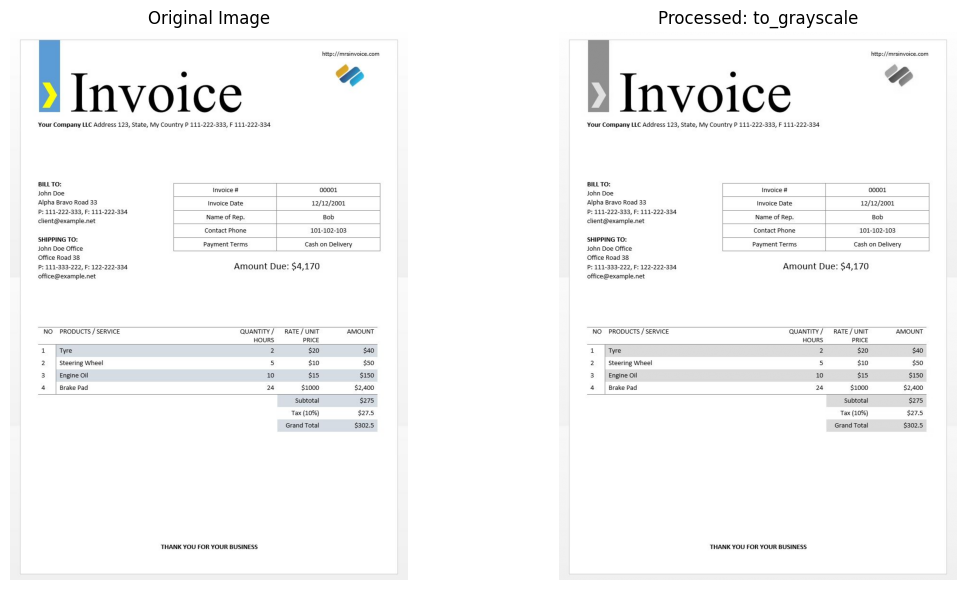

In [10]:
invoice1_gray = debug_preprocessing_step(image="data/invoice1.jpg", processing_function=to_grayscale)

In [46]:
cv.imshow("invoice1", invoice1_gray)
cv.waitKey(0)
cv.destroyAllWindows()

In [51]:
invoice1_gray

array([[254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254],
       ...,
       [240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240]],
      shape=(1150, 835), dtype=uint8)

In [11]:
def binarize_otsu(gray_image: np.ndarray) -> np.ndarray:
    """
    Convert an image to binary using Otsu thresholding.
    """

    _, binary_image = cv.threshold(
        gray_image,
        0,
        255,
        cv.THRESH_BINARY + cv.THRESH_OTSU
    )

    return binary_image

Processing function : binarize_otsu
Original shape      : (1150, 835)
Processed shape     : (1150, 835)
Original dtype      : uint8
Processed dtype     : uint8


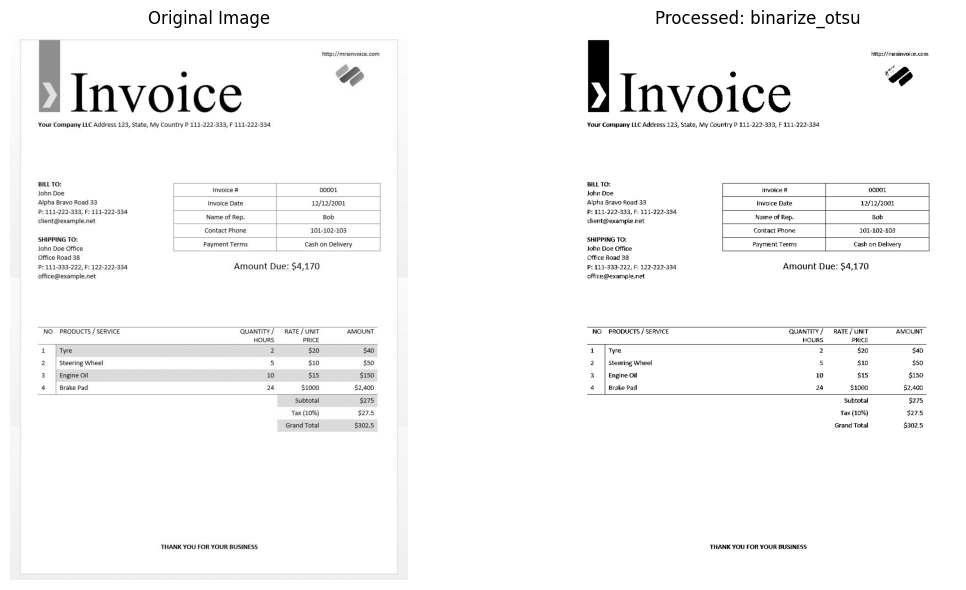

In [12]:
invoice_binary = debug_preprocessing_step(image=invoice1_gray, processing_function=binarize_otsu)

In [14]:
invoice23 = cv.imread("data/invoice23.png")

(3316, 2544, 3)

Processing function : binarize_otsu
Original shape      : (3316, 2544)
Processed shape     : (3316, 2544)
Original dtype      : uint8
Processed dtype     : uint8


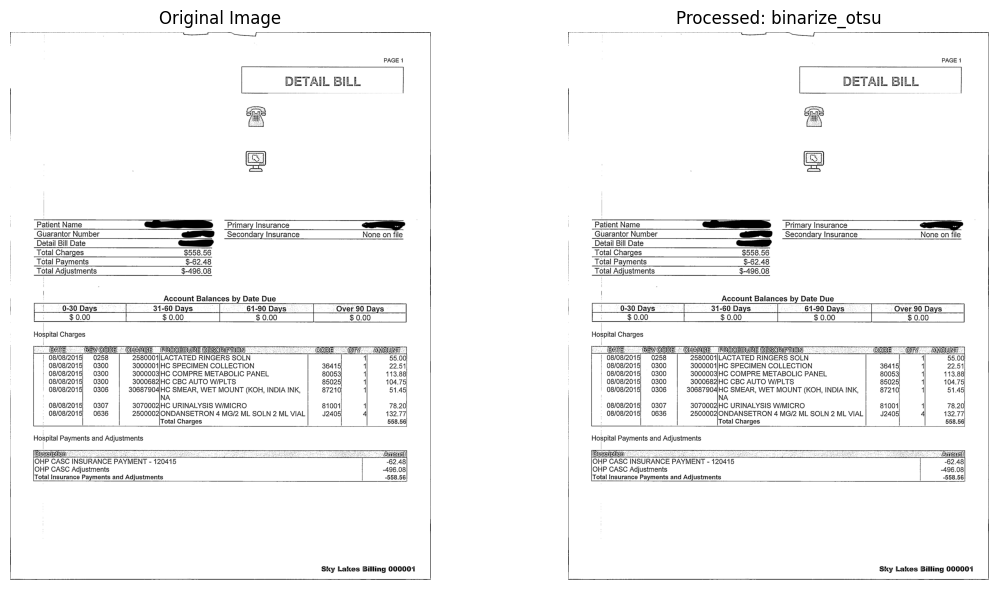

In [18]:
invoice23 = debug_preprocessing_step(image=invoice23, processing_function=binarize_otsu)

Processing function : binarize_otsu
Original shape      : (203, 248)
Processed shape     : (203, 248)
Original dtype      : uint8
Processed dtype     : uint8


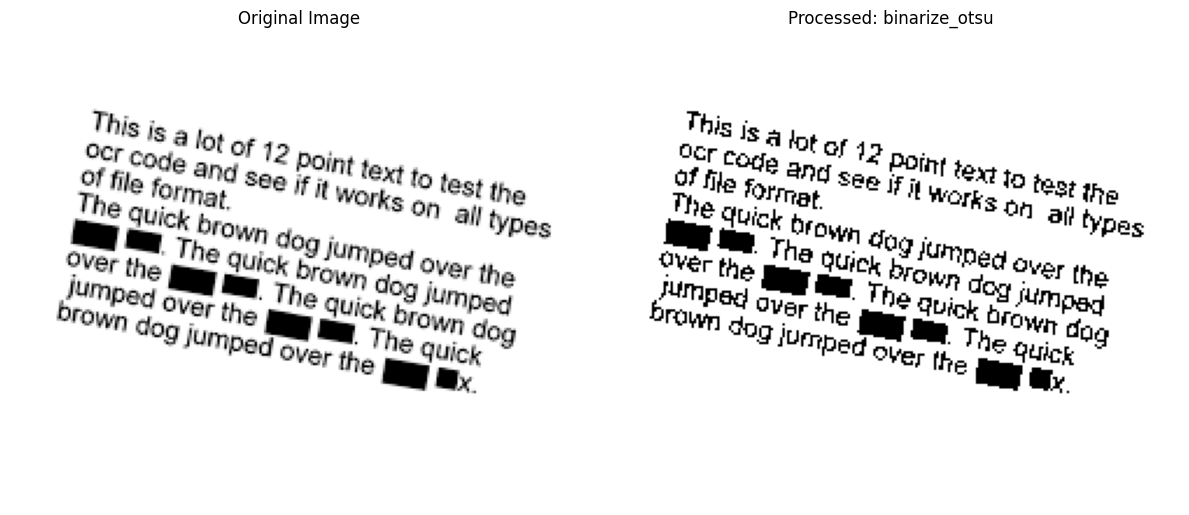

In [61]:
skeweed_bin = debug_preprocessing_step(image=skeweed_gray, processing_function=binarize_otsu)

In [23]:
cv.imwrite("invoice23-binary.png", invoice23)

True

In [67]:
if invoice is None:
    print("NO img here go away")
else: 
    cv.imshow("invoice binary", deskwed)
    cv.waitKey(0)
    cv.destroyAllWindows()

In [40]:
def denoise_median(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """
    Denoise an image using median blur.
    """
    if kernel_size % 2 == 0 or kernel_size <= 1:
        raise ValueError("kernel_size must be an odd integer greater than 1.")

    denoised_image = cv.medianBlur(image, kernel_size)
    return denoised_image

In [44]:
inv_deniose= denoise_median(invoice_binary)

In [38]:
cv.imwrite("skweed.png", skwe_denoise)

True

In [70]:
def estimate_skew_angle_from_binary(binary_image: np.ndarray) -> float:
    """
    Estimate skew angle from a binary image only.
    Does not rotate. Does not preprocess.
    """
    if len(binary_image.shape) != 2:
        raise ValueError("binary_image must be single-channel.")

    inverted = cv.bitwise_not(binary_image)
    coords = np.column_stack(np.where(inverted > 0))

    if len(coords) == 0:
        print("[deskew-debug] No foreground pixels found.")
        return 0.0

    rect = cv.minAreaRect(coords)
    (_, (w_rect, h_rect), raw_angle) = rect

    print(f"[deskew-debug] w_rect={w_rect:.2f}")
    print(f"[deskew-debug] h_rect={h_rect:.2f}")
    print(f"[deskew-debug] raw_angle={raw_angle:.2f}")

    # Try normalization
    if w_rect < h_rect:
        normalized_angle = raw_angle - 90
    else:
        normalized_angle = raw_angle

    print(f"[deskew-debug] normalized_angle={normalized_angle:.2f}")

    return normalized_angle

In [71]:
def rotate_image(image: np.ndarray, angle: float) -> np.ndarray:
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    return cv.warpAffine(
        image,
        M,
        (w, h),
        flags=cv.INTER_CUBIC,
        borderMode=cv.BORDER_REPLICATE
    )

In [74]:
angle = estimate_skew_angle_from_binary(skeweed_bin)

rot1 = rotate_image(skeweed_gray, angle)
rot2 = rotate_image(skeweed_gray, -angle)

cv.imwrite("rot_angle.png", rot1)
cv.imwrite("rot_neg_angle.png", rot2)

[deskew-debug] w_rect=201.65
[deskew-debug] h_rect=92.95
[deskew-debug] raw_angle=79.64
[deskew-debug] normalized_angle=79.64


True

In [66]:
# angle take binary and apply deskew take gray 
angle = estimate_skew_angle_from_binary(skeweed_bin)
deskwed = apply_deskew(skeweed_gray, angle)

[deskew-debug] w_rect=201.65, h_rect=92.95, raw_angle=79.64
[deskew-debug] normalized_angle=79.64


In [68]:
cv.imwrite("deskwe.png", deskwed)

True

In [75]:
import pytesseract

def run_tesseract_ocr(image: np.ndarray, config: str = "") -> str:
    """
    Run Tesseract OCR on an input image and return recognized text.
    This function only performs OCR.
    """
    text = pytesseract.image_to_string(image, config=config)
    return text

In [76]:
invoice_text = run_tesseract_ocr(invoice1_gray)

In [77]:
invoice_text

"' Invoice\n\nYour Company LLC Address 123, State, My Country P 111-222-333, F 111-222-334\n\nBILL TO:\nJohn Doe\n\nAlpha Bravo Road 33\n\nP: 111-222-338, F: 111-222-834\nclient@example.net\n\nSHIPPING TO:\nJohn Doe Office\n\nOffice Road 38\n\nP: 111-383-222, F: 122-222-334\noffice@example.net\n\nhttp://mrsinvoice.com\n\nInvoice # 00001\nInvoice Date 12/12/2001\nName of Rep. Bob\n\nContact Phone 101-102-103\n\nPayment Terms\n\nCash on Delivery\n\nAmount Due: $4,170\n\nNO PRODUCTS / SERVICE QUANTITY / RATE / UNIT AMOUNT\nHOURS PRICE\n\n1 tye 2 $20 $40\n\n2__| Steering Wheel 5 $10 $50\n\n3 | Engine oil 10 $15 $150\n\n4 | Brake Pad 24 $1000 $2,400\n\nSubtotal $275\n\nTax (10%) $27.5\n\nGrand Total $202.5\n\n‘THANK YOU FOR YOUR BUSINESS\n"